Pipe length L        : 150.0 m
True attenuation coef: 0.01 1/m
Leak samples         : 300
ROC AUC = 0.9821
Optimal threshold (Youden's J) = 0.7613
     threshold_type  threshold  sensitivity_same  false_positive_diff
0  optimal (Youden)     0.7613               1.0               0.0833
1   reference (0.7)     0.7000               1.0               0.1267

Saved: ../results/tables/same_pipe_decision.csv
Saved: ../results/figures/same_pipe_roc.png and same_pipe_roc.pdf


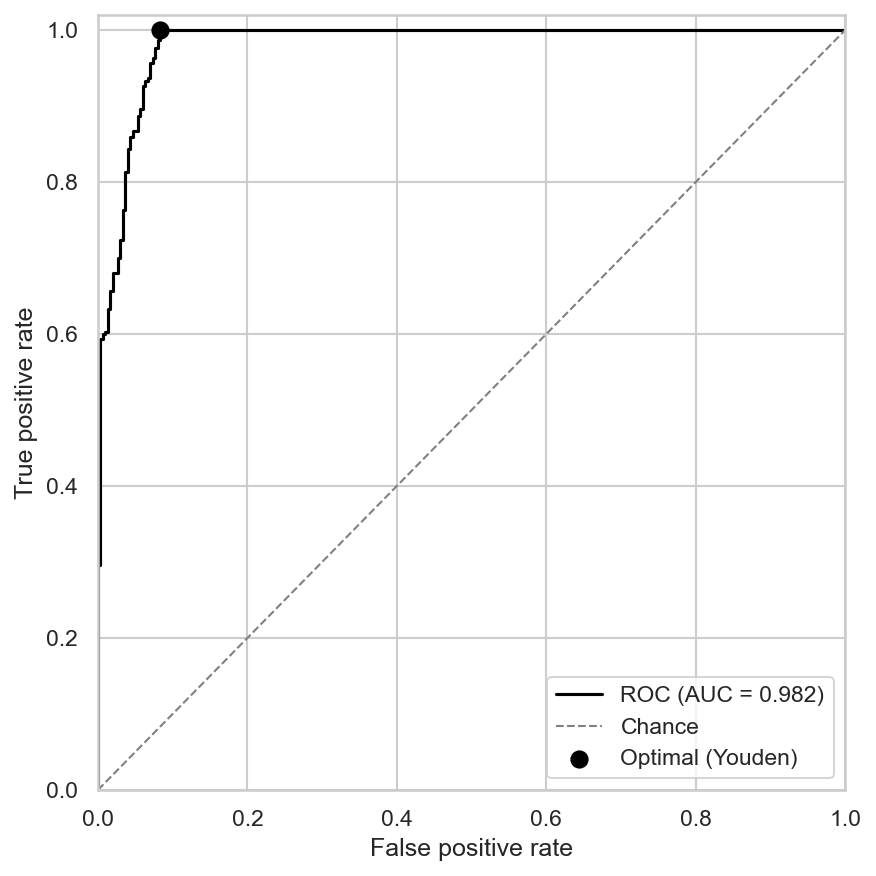

Saved: ../results/figures/same_pipe_scores.png and same_pipe_scores.pdf


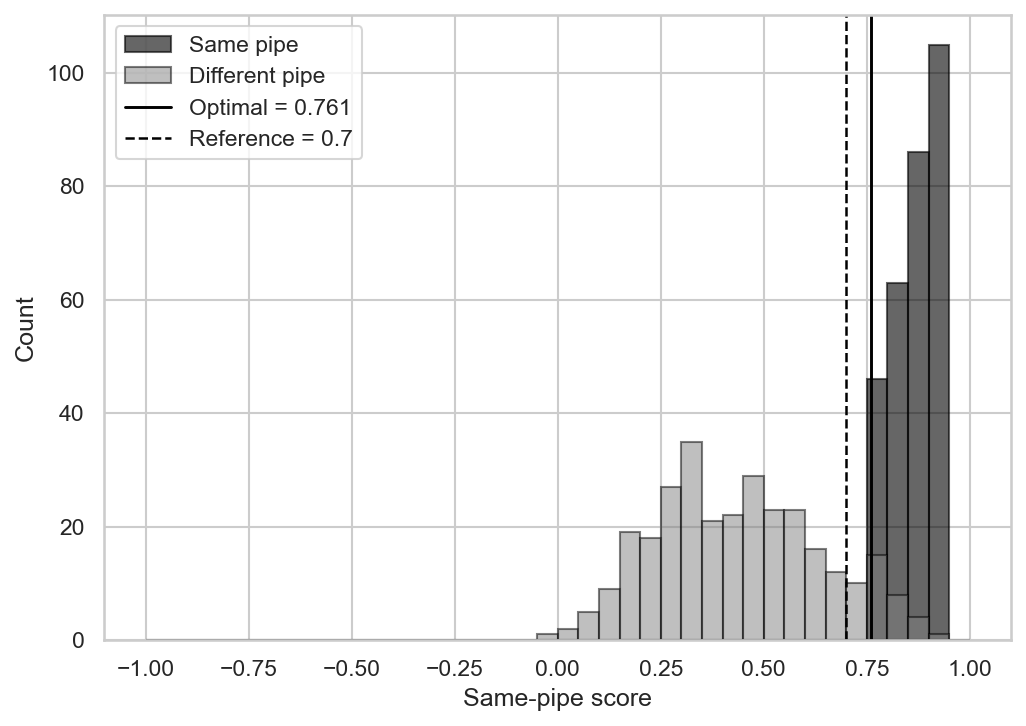

Saved: ../results/figures/correlation_hist.png and correlation_hist.pdf


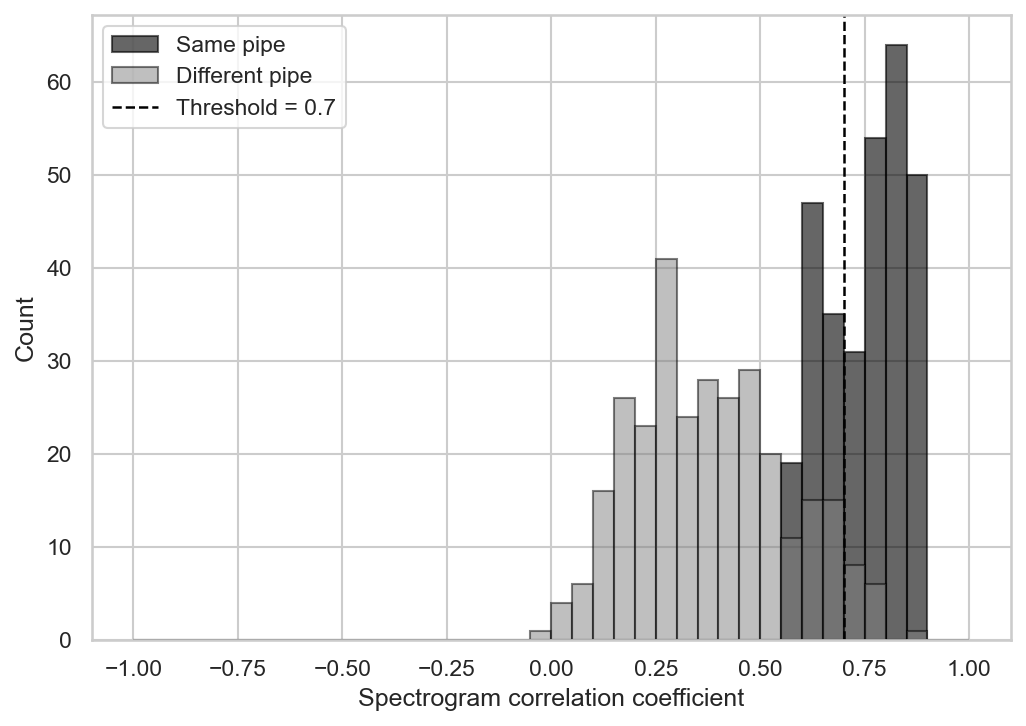

Spectrogram energy A range: [0.000165, 0.000651]
Spectrogram energy B range: [0.000163, 0.000653]
                       model   MAE_m   RMSE_m  bias_m
0  Exponential (spectrogram)  0.4821   0.6953  0.0400
1      Inverse (spectrogram)  9.9181  11.8004 -0.4519
2  Exponential (time-series)  0.3355   0.4513 -0.0021
3      Inverse (time-series)  9.9295  11.8043 -0.4805

Saved: ../results/tables/localization_error.csv
Saved: ../results/figures/localization_scatter.png and localization_scatter.pdf


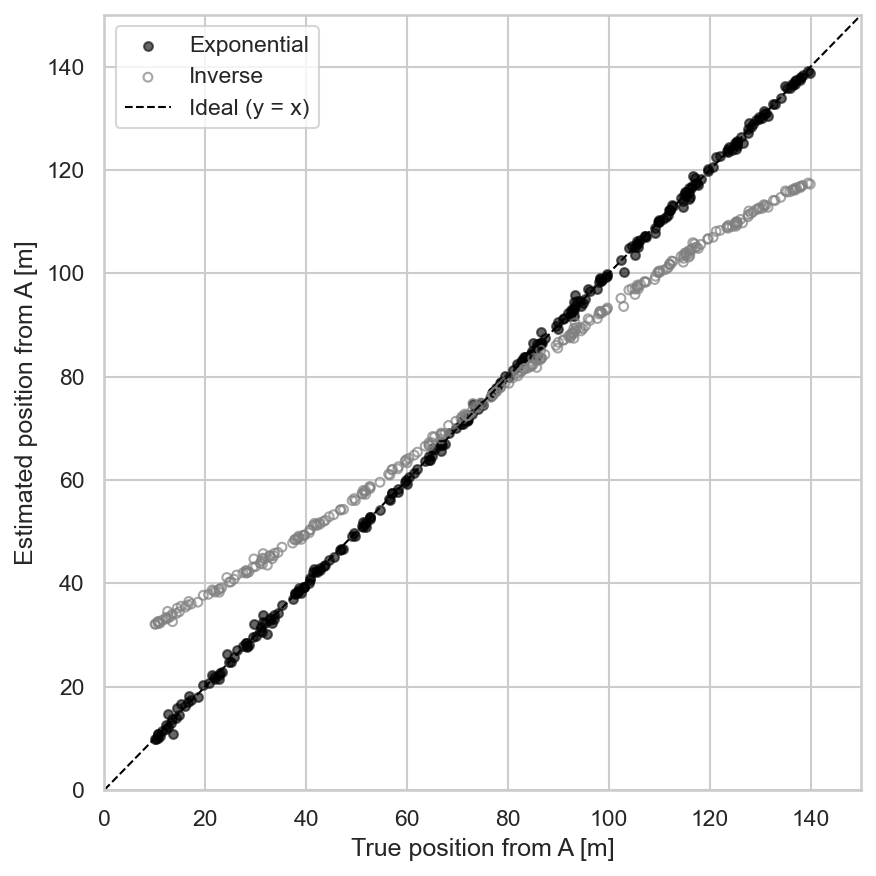

Saved: ../results/figures/error_distribution.png and error_distribution.pdf


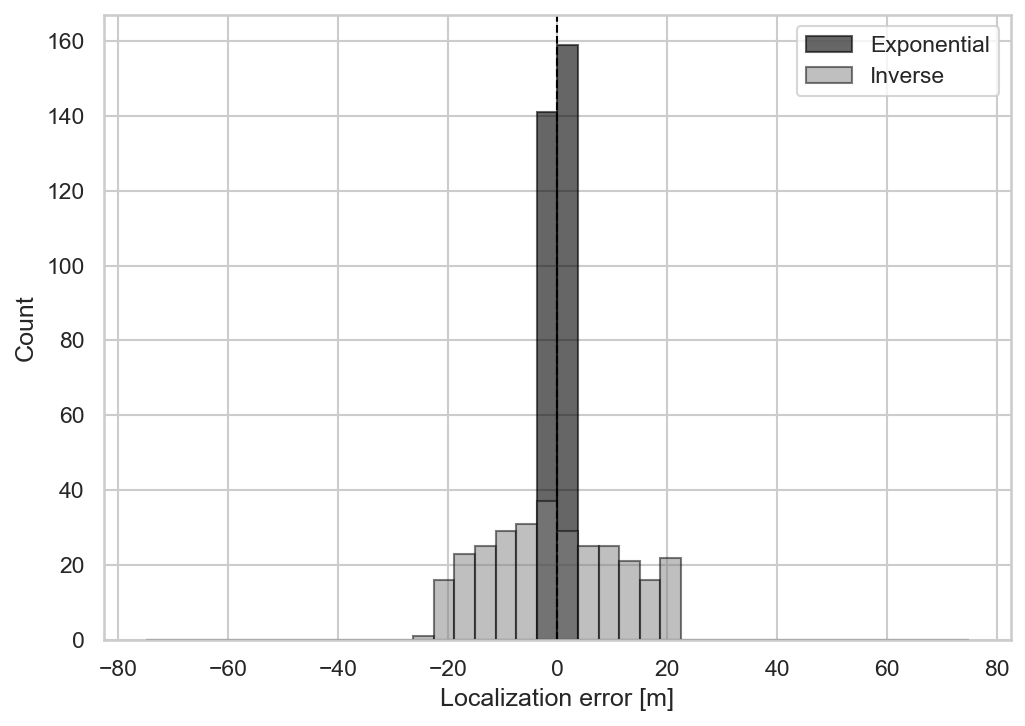

   alpha_factor  alpha_used    MAE_m   RMSE_m
0           0.5       0.005  21.2149  23.5535
1           0.7       0.007  12.4041  13.9157
2           0.8       0.008   8.0125   9.0836
3           0.9       0.009   3.7389   4.3102
4           1.0       0.010   0.4821   0.6953
5           1.1       0.011   3.0287   3.5377
6           1.2       0.012   5.5311   6.4025
7           1.5       0.015  11.0770  12.7546
8           2.0       0.020  16.6233  19.1192

Saved: ../results/tables/sensitivity_alpha.csv
Saved: ../results/figures/sensitivity_alpha.png and sensitivity_alpha.pdf


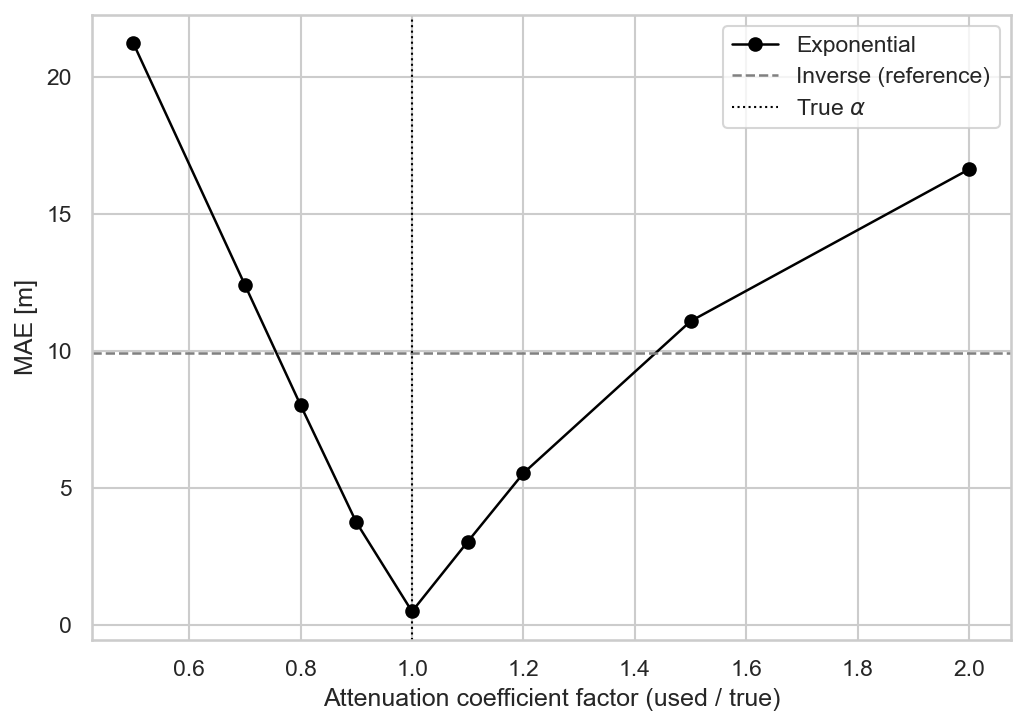

  snr_bin_db   n  MAE_exp_m  MAE_inv_m
0        5-8  69     0.8831    10.0588
1       8-11  48     0.5890    10.9317
2      11-14  58     0.4012     8.9263
3      14-17  59     0.2716     9.5598
4      17-20  66     0.2447    10.2258

Saved: ../results/tables/sensitivity_snr.csv
Saved: ../results/figures/sensitivity_snr.png and sensitivity_snr.pdf


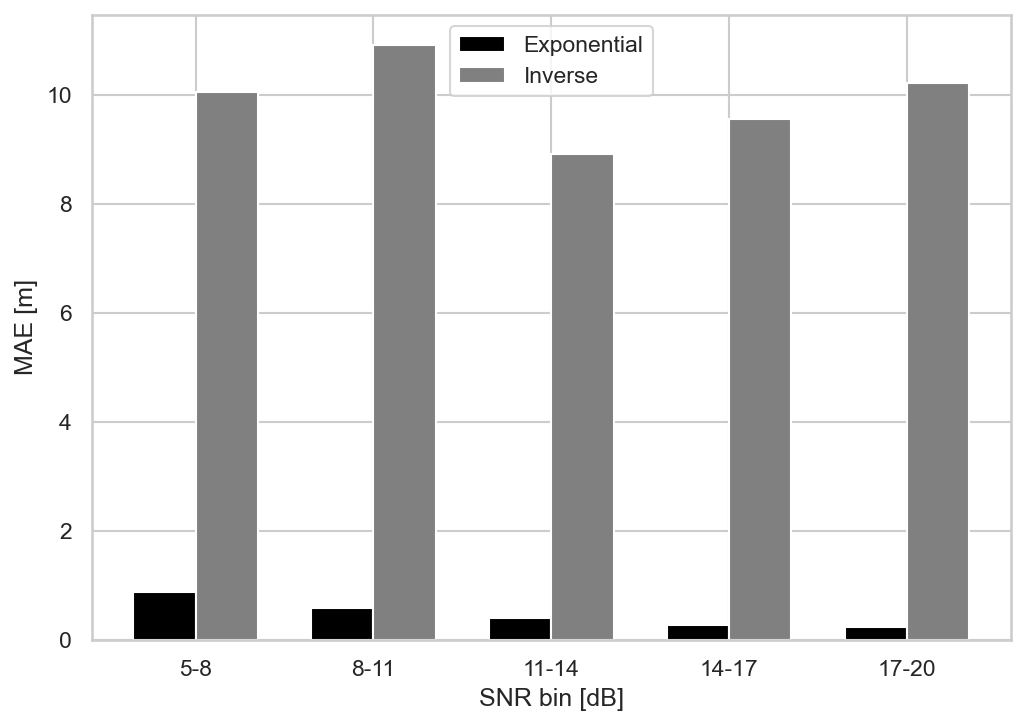

In [4]:
# ============================================================
# Notebook: 04_localization.ipynb
# Purpose : Estimate leak position from acoustic energy measured at
#           two points (A, B). First decide whether two measurements
#           come from the SAME pipe via spectrogram correlation, then
#           localize the leak using two attenuation models:
#             (1) Exponential attenuation  (main, re-derived model)
#             (2) Energy-distance inverse  (special-case model)
#           Estimated positions are compared against the known
#           ground-truth positions to quantify error (MAE, RMSE),
#           followed by sensitivity analyses.
#
#           Localization energies come from the ABSOLUTE spectrogram
#           pattern energies stored by notebook 02 (energyA/energyB),
#           NOT from the per-image normalized spectrograms, so that
#           the true A-vs-B energy scale is preserved.
# Inputs  : ../data/signals.npz
#           ../data/labels.csv
#           ../data/spectrograms.npz
# Outputs : ../results/tables/same_pipe_decision.csv
#           ../results/tables/localization_error.csv
#           ../results/tables/sensitivity_alpha.csv
#           ../results/tables/sensitivity_snr.csv
#           ../results/figures/correlation_hist.(png/pdf)
#           ../results/figures/localization_scatter.(png/pdf)
#           ../results/figures/error_distribution.(png/pdf)
#           ../results/figures/sensitivity_alpha.(png/pdf)
#           ../results/figures/sensitivity_snr.(png/pdf)
# ============================================================

# ------------------------------------------------------------
# Cell 1 — Imports, configuration, and plotting helper
# ------------------------------------------------------------
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
rng = np.random.default_rng(SEED)

DATA_DIR = "../data"
FIG_DIR = "../results/figures"
TAB_DIR = "../results/tables"
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TAB_DIR, exist_ok=True)

sns.set_theme(style="whitegrid")
sns.set_palette("gray")
plt.rcParams["image.cmap"] = "gray"
plt.rcParams["savefig.dpi"] = 600
plt.rcParams["figure.dpi"] = 150

def save_figure(fig, name, fig_dir=FIG_DIR, dpi=600):
    for ext in ("png", "pdf"):
        path = os.path.join(fig_dir, f"{name}.{ext}")
        fig.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Saved: {fig_dir}/{name}.png and {name}.pdf")


# ------------------------------------------------------------
# Cell 2 — Load signals, labels, and spectrograms
# ------------------------------------------------------------
sig_data = np.load(os.path.join(DATA_DIR, "signals.npz"))
PIPE_LENGTH = float(sig_data["pipe_length"])     # L [m]
ALPHA_TRUE = float(sig_data["alpha"])            # true attenuation coeff

labels_df = pd.read_csv(os.path.join(DATA_DIR, "labels.csv"))

spec_data = np.load(os.path.join(DATA_DIR, "spectrograms.npz"),
                    allow_pickle=True)
specA_clean = spec_data["specA_clean"]           # (Nsig, H, W) normalized, A
specB_clean = spec_data["specB_clean"]           # (Nsig, H, W) normalized, B
energyA_all = spec_data["energyA"]               # (Nsig,) absolute energy, A
energyB_all = spec_data["energyB"]               # (Nsig,) absolute energy, B

# Restrict localization to leak samples only (non-leak has no target).
leak_mask = labels_df["label"].values == "leak"
leak_idx = np.where(leak_mask)[0]

print(f"Pipe length L        : {PIPE_LENGTH} m")
print(f"True attenuation coef: {ALPHA_TRUE} 1/m")
print(f"Leak samples         : {len(leak_idx)}")


# ------------------------------------------------------------
# Cell 3 — Same-pipe decision: features and ROC-based threshold
# ------------------------------------------------------------
# Deciding whether two measurements come from the same pipe is a
# binary problem: same-pipe (positive) vs different-pipe (negative).
# The per-image normalized spectrogram correlation alone is sensitive
# to A-vs-B energy imbalance, so we combine it with a frequency-
# profile correlation that is robust to amplitude normalization:
# leak sounds from the same pipe share a dominant frequency band even
# when their overall levels differ.
#
# We then choose the decision threshold from data using an ROC curve
# (Youden's J), rather than a hard-coded constant. The original 0.7
# threshold is kept as a reference line.
from sklearn.metrics import roc_curve, auc

CORR_THRESHOLD_REF = 0.7      # original hard-coded reference

# --- Feature 1: full spectrogram image correlation ---
def spectrogram_correlation(imgA, imgB):
    a = imgA.ravel() - imgA.mean()
    b = imgB.ravel() - imgB.mean()
    denom = np.sqrt(np.sum(a ** 2) * np.sum(b ** 2)) + 1e-12
    return float(np.sum(a * b) / denom)

# --- Feature 2: frequency-profile correlation (time-averaged) ---
# Collapse each spectrogram over time to a frequency profile, then
# correlate. This isolates the spectral structure of the leak and is
# insensitive to per-image amplitude normalization.
def frequency_profile_correlation(imgA, imgB):
    pa = imgA.mean(axis=1)     # average over time frames -> freq profile
    pb = imgB.mean(axis=1)
    pa = pa - pa.mean()
    pb = pb - pb.mean()
    denom = np.sqrt(np.sum(pa ** 2) * np.sum(pb ** 2)) + 1e-12
    return float(np.sum(pa * pb) / denom)

# Combined same-pipe score: mean of the two correlation features.
def same_pipe_score(imgA, imgB):
    c_img = spectrogram_correlation(imgA, imgB)
    c_freq = frequency_profile_correlation(imgA, imgB)
    return 0.5 * (c_img + c_freq)

# Same-pipe pairs (true A-B pairs of the same leak sample)
same_scores = np.array([same_pipe_score(specA_clean[i], specB_clean[i])
                        for i in leak_idx])

# Different-pipe pairs (A of one leak vs B of another, shuffled)
shuffled = rng.permutation(leak_idx)
diff_pairs = [(i, j) for i, j in zip(leak_idx, shuffled) if i != j]
diff_scores = np.array([same_pipe_score(specA_clean[i], specB_clean[j])
                        for i, j in diff_pairs])

# Build labels/scores for ROC: 1 = same-pipe, 0 = different-pipe
y_true = np.concatenate([np.ones_like(same_scores),
                         np.zeros_like(diff_scores)])
y_score = np.concatenate([same_scores, diff_scores])

fpr, tpr, thr = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

# Youden's J optimal threshold
J = tpr - fpr
best_k = int(np.argmax(J))
opt_threshold = float(thr[best_k])

# Performance at the optimal threshold
same_pass_opt = float(np.mean(same_scores >= opt_threshold))   # sensitivity
diff_pass_opt = float(np.mean(diff_scores >= opt_threshold))   # 1 - specificity
# Performance at the original 0.7 reference threshold
same_pass_ref = float(np.mean(same_scores >= CORR_THRESHOLD_REF))
diff_pass_ref = float(np.mean(diff_scores >= CORR_THRESHOLD_REF))

decision_df = pd.DataFrame({
    "threshold_type": ["optimal (Youden)", "reference (0.7)"],
    "threshold": [opt_threshold, CORR_THRESHOLD_REF],
    "sensitivity_same": [same_pass_opt, same_pass_ref],
    "false_positive_diff": [diff_pass_opt, diff_pass_ref],
}).round(4)
decision_df.to_csv(os.path.join(TAB_DIR, "same_pipe_decision.csv"),
                   index=False)
print(f"ROC AUC = {roc_auc:.4f}")
print(f"Optimal threshold (Youden's J) = {opt_threshold:.4f}")
print(decision_df)
print("\nSaved: ../results/tables/same_pipe_decision.csv")


# ------------------------------------------------------------
# Cell 4 — Same-pipe decision figures (ROC + score distributions)
# ------------------------------------------------------------
# Two grayscale figures: (a) ROC curve with the optimal operating
# point marked; (b) overlaid score distributions with the optimal and
# reference thresholds. No titles/captions.

# (a) ROC curve
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr, tpr, color="black", linewidth=1.5,
        label=f"ROC (AUC = {roc_auc:.3f})")
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1.0,
        label="Chance")
ax.scatter([fpr[best_k]], [tpr[best_k]], s=60, color="black",
           zorder=5, label="Optimal (Youden)")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
ax.legend(loc="lower right")
plt.tight_layout()
save_figure(fig, "same_pipe_roc")
plt.show()

# (b) Score distributions with thresholds
fig, ax = plt.subplots(figsize=(7, 5))
bins = np.linspace(-1, 1, 41)
ax.hist(same_scores, bins=bins, color="black", alpha=0.6,
        label="Same pipe", edgecolor="black")
ax.hist(diff_scores, bins=bins, color="gray", alpha=0.5,
        label="Different pipe", edgecolor="black")
ax.axvline(opt_threshold, color="black", linestyle="-", linewidth=1.4,
           label=f"Optimal = {opt_threshold:.3f}")
ax.axvline(CORR_THRESHOLD_REF, color="black", linestyle="--", linewidth=1.2,
           label="Reference = 0.7")
ax.set_xlabel("Same-pipe score")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
save_figure(fig, "same_pipe_scores")
plt.show()


# ------------------------------------------------------------
# Cell 4 — Correlation distribution figure
# ------------------------------------------------------------
# Overlaid histograms of same-pipe vs different-pipe correlations,
# with the decision threshold marked. Grayscale, no title/caption.
fig, ax = plt.subplots(figsize=(7, 5))
bins = np.linspace(-1, 1, 41)
ax.hist(same_corrs, bins=bins, color="black", alpha=0.6,
        label="Same pipe", edgecolor="black")
ax.hist(diff_corrs, bins=bins, color="gray", alpha=0.5,
        label="Different pipe", edgecolor="black")
ax.axvline(CORR_THRESHOLD, color="black", linestyle="--", linewidth=1.2,
           label=f"Threshold = {CORR_THRESHOLD}")
ax.set_xlabel("Spectrogram correlation coefficient")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
save_figure(fig, "correlation_hist")
plt.show()


# ------------------------------------------------------------
# Cell 5 — Retrieve absolute pattern energies (main method)
# ------------------------------------------------------------
# Localization energies are the ABSOLUTE spectrogram pattern energies
# computed in notebook 02 BEFORE per-image normalization. These
# preserve the true A-vs-B energy ratio that the attenuation models
# rely on. The per-image normalized spectrograms are used only for
# the correlation-based same-pipe decision above, not here.
E_A_spec = energyA_all[leak_idx].astype(np.float64)
E_B_spec = energyB_all[leak_idx].astype(np.float64)

# Time-series energies (independent verification, precomputed in 01)
E_A_ts = labels_df.loc[leak_idx, "E_A"].values
E_B_ts = labels_df.loc[leak_idx, "E_B"].values

# Ground-truth positions from A
x_true = labels_df.loc[leak_idx, "x_true"].values

print(f"Spectrogram energy A range: [{E_A_spec.min():.3g}, {E_A_spec.max():.3g}]")
print(f"Spectrogram energy B range: [{E_B_spec.min():.3g}, {E_B_spec.max():.3g}]")


# ------------------------------------------------------------
# Cell 6 — Localization models
# ------------------------------------------------------------
# Model 1 (main): exponential attenuation, re-derived.
#   E_A = E0 exp(-alpha x_A), E_B = E0 exp(-alpha x_B), x_A + x_B = L
#   => x_A = L/2 - (1 / (2 alpha)) * ln(E_A / E_B)
# Model 2 (special case): energy-distance inverse (E ∝ 1/x).
#   E_A x_A = E_B x_B  =>  x_A = E_B / (E_A + E_B) * L
#
# NOTE ON SCALE: the exponential model's ln(E_A/E_B) assumes energies
# on the same physical scale as the generative model. Spectrogram
# pattern energy is proportional to signal power, i.e. to amplitude^2,
# just like the time-series energy, so the ratio is scale-consistent.
def localize_exponential(E_A, E_B, L, alpha):
    xA = L / 2.0 - (1.0 / (2.0 * alpha)) * np.log(E_A / E_B)
    return np.clip(xA, 0.0, L)          # physical bound [0, L]

def localize_inverse(E_A, E_B, L):
    xA = E_B / (E_A + E_B) * L
    return np.clip(xA, 0.0, L)

# Estimate positions using the spectrogram-based energies (main).
# The exponential model requires an attenuation coefficient; here we
# use the true alpha (a dedicated sensitivity analysis on alpha
# mismatch follows in Cell 9).
xA_exp = localize_exponential(E_A_spec, E_B_spec, PIPE_LENGTH, ALPHA_TRUE)
xA_inv = localize_inverse(E_A_spec, E_B_spec, PIPE_LENGTH)

# Verification estimates using time-series energies.
xA_exp_ts = localize_exponential(E_A_ts, E_B_ts, PIPE_LENGTH, ALPHA_TRUE)
xA_inv_ts = localize_inverse(E_A_ts, E_B_ts, PIPE_LENGTH)


# ------------------------------------------------------------
# Cell 7 — Localization error metrics
# ------------------------------------------------------------
def error_metrics(x_hat, x_ref):
    err = x_hat - x_ref
    mae = float(np.mean(np.abs(err)))
    rmse = float(np.sqrt(np.mean(err ** 2)))
    bias = float(np.mean(err))
    return mae, rmse, bias

rows = []
for name, xhat in [
    ("Exponential (spectrogram)", xA_exp),
    ("Inverse (spectrogram)", xA_inv),
    ("Exponential (time-series)", xA_exp_ts),
    ("Inverse (time-series)", xA_inv_ts),
]:
    mae, rmse, bias = error_metrics(xhat, x_true)
    rows.append({"model": name, "MAE_m": mae, "RMSE_m": rmse, "bias_m": bias})

error_df = pd.DataFrame(rows).round(4)
error_df.to_csv(os.path.join(TAB_DIR, "localization_error.csv"), index=False)
print(error_df)
print("\nSaved: ../results/tables/localization_error.csv")


# ------------------------------------------------------------
# Cell 8 — Estimated vs true position scatter, and error distribution
# ------------------------------------------------------------
# Scatter: estimated vs true position for both spectrogram-based
# models, with the ideal y=x reference line. Grayscale, no caption.
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(x_true, xA_exp, s=18, color="black", alpha=0.6,
           label="Exponential")
ax.scatter(x_true, xA_inv, s=18, facecolors="none", edgecolors="gray",
           alpha=0.7, label="Inverse")
lims = [0, PIPE_LENGTH]
ax.plot(lims, lims, color="black", linestyle="--", linewidth=1.0,
        label="Ideal (y = x)")
ax.set_xlabel("True position from A [m]")
ax.set_ylabel("Estimated position from A [m]")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.legend()
plt.tight_layout()
save_figure(fig, "localization_scatter")
plt.show()

# Error distribution: histograms of signed error for both models.
fig, ax = plt.subplots(figsize=(7, 5))
bins = np.linspace(-PIPE_LENGTH / 2, PIPE_LENGTH / 2, 41)
ax.hist(xA_exp - x_true, bins=bins, color="black", alpha=0.6,
        label="Exponential", edgecolor="black")
ax.hist(xA_inv - x_true, bins=bins, color="gray", alpha=0.5,
        label="Inverse", edgecolor="black")
ax.axvline(0, color="black", linestyle="--", linewidth=1.0)
ax.set_xlabel("Localization error [m]")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
save_figure(fig, "error_distribution")
plt.show()


# ------------------------------------------------------------
# Cell 9 — Sensitivity analysis: attenuation coefficient mismatch
# ------------------------------------------------------------
# In practice the true alpha is unknown and must be calibrated. We
# apply the exponential model with a MISspecified alpha (scaled by a
# factor relative to the true value) and measure how MAE degrades.
# The inverse model does not use alpha, so it appears as a flat
# reference line.
ALPHA_FACTORS = [0.5, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.5, 2.0]

alpha_rows = []
for fac in ALPHA_FACTORS:
    alpha_used = ALPHA_TRUE * fac
    xhat = localize_exponential(E_A_spec, E_B_spec, PIPE_LENGTH, alpha_used)
    mae, rmse, _ = error_metrics(xhat, x_true)
    alpha_rows.append({"alpha_factor": fac, "alpha_used": alpha_used,
                       "MAE_m": mae, "RMSE_m": rmse})

alpha_df = pd.DataFrame(alpha_rows).round(4)
alpha_df.to_csv(os.path.join(TAB_DIR, "sensitivity_alpha.csv"), index=False)
print(alpha_df)
print("\nSaved: ../results/tables/sensitivity_alpha.csv")

# Reference MAE of the inverse model (alpha-independent)
inv_mae, _, _ = error_metrics(xA_inv, x_true)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(alpha_df["alpha_factor"], alpha_df["MAE_m"], marker="o",
        color="black", linewidth=1.2, label="Exponential")
ax.axhline(inv_mae, color="gray", linestyle="--", linewidth=1.2,
           label="Inverse (reference)")
ax.axvline(1.0, color="black", linestyle=":", linewidth=1.0,
           label="True $\\alpha$")
ax.set_xlabel("Attenuation coefficient factor (used / true)")
ax.set_ylabel("MAE [m]")
ax.legend()
plt.tight_layout()
save_figure(fig, "sensitivity_alpha")
plt.show()


# ------------------------------------------------------------
# Cell 10 — Sensitivity analysis: measurement noise (SNR)
# ------------------------------------------------------------
# Group leak samples by their acquisition SNR into bins and report
# localization MAE per bin for both spectrogram-based models. Lower
# SNR is expected to increase error, especially for the exponential
# model that depends on an energy ratio.
snr = labels_df.loc[leak_idx, "snr_db"].values
snr_bins = [5, 8, 11, 14, 17, 20]
bin_labels = [f"{snr_bins[k]}-{snr_bins[k+1]}" for k in range(len(snr_bins)-1)]
bin_idx = np.digitize(snr, snr_bins, right=False) - 1

snr_rows = []
for b, lab in enumerate(bin_labels):
    m = bin_idx == b
    if np.sum(m) == 0:
        continue
    mae_exp, _, _ = error_metrics(xA_exp[m], x_true[m])
    mae_inv, _, _ = error_metrics(xA_inv[m], x_true[m])
    snr_rows.append({"snr_bin_db": lab, "n": int(np.sum(m)),
                     "MAE_exp_m": mae_exp, "MAE_inv_m": mae_inv})

snr_df = pd.DataFrame(snr_rows).round(4)
snr_df.to_csv(os.path.join(TAB_DIR, "sensitivity_snr.csv"), index=False)
print(snr_df)
print("\nSaved: ../results/tables/sensitivity_snr.csv")

x_pos = np.arange(len(snr_df))
width = 0.35
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(x_pos - width/2, snr_df["MAE_exp_m"], width, color="black",
       label="Exponential")
ax.bar(x_pos + width/2, snr_df["MAE_inv_m"], width, color="gray",
       label="Inverse")
ax.set_xticks(x_pos)
ax.set_xticklabels(snr_df["snr_bin_db"])
ax.set_xlabel("SNR bin [dB]")
ax.set_ylabel("MAE [m]")
ax.legend()
plt.tight_layout()
save_figure(fig, "sensitivity_snr")
plt.show()